In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

In [2]:
pos_data=pd.read_csv("POS_CASH_balance.csv")
pos_data.shape

(10001358, 8)

In [3]:
pos_data.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [4]:
pos_data.isnull().sum()

SK_ID_PREV                   0
SK_ID_CURR                   0
MONTHS_BALANCE               0
CNT_INSTALMENT           26071
CNT_INSTALMENT_FUTURE    26087
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64

In [5]:
'''
curr_prev_table stores the unique mapping of previous loans to current loans as a dataframe
'''
curr_prev_table=pos_data[['SK_ID_CURR', 'SK_ID_PREV']].drop_duplicates()
curr_prev_table.head()

,SK_ID_CURR,SK_ID_PREV
0,182943,1803195
1,367990,1715348
2,397406,1784872
3,269225,1903291
4,334279,2341044


### Aggregation Based on SK_ID_PREV

In [6]:
group=pos_data.groupby(by='SK_ID_PREV')

In [7]:
pos_agg=group.agg(func={'CNT_INSTALMENT':  ['min', 'max'], 'SK_ID_PREV': 'count', 
                'SK_DPD': 'max', 'SK_DPD_DEF': 'max'})
pos_agg.head()

CNT_INSTALMENT       SK_ID_PREV SK_DPD SK_DPD_DEF
                      min   max      count    max        max
SK_ID_PREV                                                  
1000001               2.0  12.0          3      0          0
1000002               4.0   6.0          5      0          0
1000003              12.0  12.0          4      0          0
1000004               7.0  10.0          8      0          0
1000005              10.0  10.0         11      0          0

In [8]:
pos_agg.shape

(936325, 5)

In [9]:
'''
renaming columns appropriatley and flattent the dataframe
'''
pos_agg.columns=pd.Index(['_'.join(val) for val in pos_agg.columns.to_flat_index()])
pos_agg.reset_index(inplace=True)
pos_agg.head()

,SK_ID_PREV,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max
0,1000001,2.0,12.0,3,0,0
1,1000002,4.0,6.0,5,0,0
2,1000003,12.0,12.0,4,0,0
3,1000004,7.0,10.0,8,0,0
4,1000005,10.0,10.0,11,0,0


In [10]:
'''
adding INSTALMENT_REDUCTION_PCT
'''
pos_agg['INSTALMENT_REDUCTION_PCT']=(pos_agg['CNT_INSTALMENT_max']-pos_agg['CNT_INSTALMENT_min'])*100/pos_agg['CNT_INSTALMENT_max']
pos_agg.head()

,SK_ID_PREV,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max,INSTALMENT_REDUCTION_PCT
0,1000001,2.0,12.0,3,0,0,83.333333
1,1000002,4.0,6.0,5,0,0,33.333333
2,1000003,12.0,12.0,4,0,0,0.000000
3,1000004,7.0,10.0,8,0,0,30.000000
4,1000005,10.0,10.0,11,0,0,0.000000


#### Aggregating MONTH_BALANCE AND NAME_CONTRACT_STATUS

In [11]:
'''
temp will contain the indices of the max month balance corresponding to each previous loan (recent most entry).
the indices will be according to the main data(pos_data). Using temp as index the rows can be accessed that tells the recent most
entry for the previous loan. That row is used to extract the recent most status of the contract
Lastly, data is merged to update pos_agg to obtain the final table
'''
temp=group['MONTHS_BALANCE'].idxmax()
temp2=pos_data.loc[temp, ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS']]
pos_agg=pd.merge(left=temp2, right=pos_agg, on='SK_ID_PREV')
pos_agg.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,NAME_CONTRACT_STATUS,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max,INSTALMENT_REDUCTION_PCT
0,1000001,158271,-8,Completed,2.0,12.0,3,0,0,83.333333
1,1000002,101962,-50,Completed,4.0,6.0,5,0,0,33.333333
2,1000003,252457,-1,Active,12.0,12.0,4,0,0,0.000000
3,1000004,260094,-22,Completed,7.0,10.0,8,0,0,30.000000
4,1000005,176456,-46,Completed,10.0,10.0,11,0,0,0.000000


In [12]:
pos_agg.shape

(936325, 10)

### Agregating Based on SK_ID_CURR (main aggregation)

In [13]:
pos_agg.isnull().sum()

SK_ID_PREV                    0
SK_ID_CURR                    0
MONTHS_BALANCE                0
NAME_CONTRACT_STATUS          0
CNT_INSTALMENT_min          890
CNT_INSTALMENT_max          890
SK_ID_PREV_count              0
SK_DPD_max                    0
SK_DPD_DEF_max                0
INSTALMENT_REDUCTION_PCT    890
dtype: int64

In [14]:
'''
renamig columns accordingly
'''
pos_agg.rename(columns={'CNT_INSTALMENT_max': 'ORIGINAL_INSTALMENTS', 'CNT_INSTALMENT_min': 'ACTUAL_INSTALMENTS',
                        'SK_DPD_max': 'DPD', 'SK_DPD_DEF_max': 'DPD_DEF', 'SK_ID_PREV': 'PREVIOUS_LOAN', 
                        'SK_ID_PREV_count': 'RECORD_count'}, inplace=True)
pos_agg.columns.sort_values()

Index(['ACTUAL_INSTALMENTS', 'DPD', 'DPD_DEF', 'INSTALMENT_REDUCTION_PCT',
       'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS', 'ORIGINAL_INSTALMENTS',
       'PREVIOUS_LOAN', 'RECORD_count', 'SK_ID_CURR'],
      dtype='object')

In [15]:
'''
aggregating step, NAME_CONTARCT_STATUS is aggregated in the next cell as it is a categorical variable
'''
pos_agg_2=pos_agg.groupby(by='SK_ID_CURR').agg(func={'ACTUAL_INSTALMENTS': ['min', 'max', 'median', 'sum'],
                                                     'ORIGINAL_INSTALMENTS': ['min', 'max', 'median', 'sum'],
                                                     'RECORD_count': ['min', 'max', 'median', 'sum'],
                                                     'INSTALMENT_REDUCTION_PCT': ['min', 'max', 'median'],
                                                     'MONTHS_BALANCE': ['min', 'max', 'median'],
                                                     'DPD': 'sum', 'DPD_DEF': 'sum',
                                                     'PREVIOUS_LOAN': 'count'})
pos_agg_2.columns=pd.Index(['_'.join(val) for val in pos_agg_2.columns.to_flat_index()])
pos_agg_2.reset_index(inplace=True)
pos_agg_2.shape

(337252, 22)

In [16]:
'''
aggregating NAME_CONTRACT_STATUS
'''
temp3=pos_agg[['SK_ID_CURR', 'NAME_CONTRACT_STATUS']].value_counts().unstack().replace(np.nan, 0)
temp3['Total']=temp3.sum(axis=1) # temporary column, will be deleted later
temp3['Active_PCT']=temp3['Active']*100/temp3['Total']
temp3['Completed_PCT']=temp3['Completed']*100/temp3['Total']
temp3.drop(labels='Total', axis=1, inplace=True)
temp3.rename(columns=lambda x: 'CONTRACT_STATUS_'+x, inplace=True)
temp3.reset_index(inplace=True)
temp3.shape

(337252, 11)

In [17]:
'''
merging the result of the above two cells
'''
pos_agg_2=pd.merge(left=pos_agg_2, right=temp3, on='SK_ID_CURR')
pos_agg_2.shape

(337252, 32)

In [18]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
pos_agg_target=pd.merge(left=pos_agg_2, right=main_data_id_target, on='SK_ID_CURR')
pos_agg_target.shape

(289444, 33)

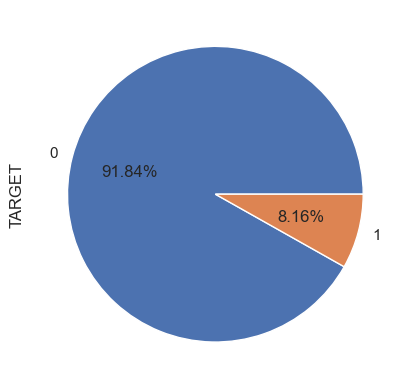

In [19]:
'''
distribution of target in the aggregated bureau data
'''
pos_agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

In [20]:
pos_agg_target.isnull().sum()

SK_ID_CURR                                0
ACTUAL_INSTALMENTS_min                   24
ACTUAL_INSTALMENTS_max                   24
ACTUAL_INSTALMENTS_median                24
ACTUAL_INSTALMENTS_sum                    0
ORIGINAL_INSTALMENTS_min                 24
ORIGINAL_INSTALMENTS_max                 24
ORIGINAL_INSTALMENTS_median              24
ORIGINAL_INSTALMENTS_sum                  0
RECORD_count_min                          0
RECORD_count_max                          0
RECORD_count_median                       0
RECORD_count_sum                          0
INSTALMENT_REDUCTION_PCT_min             24
INSTALMENT_REDUCTION_PCT_max             24
INSTALMENT_REDUCTION_PCT_median          24
MONTHS_BALANCE_min                        0
MONTHS_BALANCE_max                        0
MONTHS_BALANCE_median                     0
DPD_sum                                   0
DPD_DEF_sum                               0
PREVIOUS_LOAN_count                       0
CONTRACT_STATUS_Active          

### Functions

In [21]:
def plot_hist_box(data, feature):
    '''
    takes dataframe and a feature name, outputs a plot with boxplot and histogram of the feature
    '''
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [22]:
def plot_hist_default_pct(feature, dataframe, bins):
    '''
    takes a dataframe, a feature name and number of bins. Plots a histogram of the feature such that binning is equal width, and the value is the deafult percentage of that bin.  
    '''
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    default_counts.sort_index(inplace=True)
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [23]:
def calc_iqr(feature, data):
    '''
    takes a dataframe and a feature name, returns the the 1st quartile, 3rd quartile and the inter-quartile range
    '''
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [24]:
def plot_kde_vs_target(feature, main_data):
    '''
    takes a dataframe and a feature name, plots two kernel density plots, one for deafulter customers and other of non-deafulter customers. plots nothing of the variance of the feature is zero. 
    '''
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [25]:
def plot_all_numeric_kde(main_data, numerical_features):
    '''
    takes a dataframe and an index of feature names, plots the kernel density plots of all features present in numerical_features   
    '''
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [26]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [27]:
def median_vs_target(feature, data):
    '''
    takes a feature name and a dataframe. prints two values, one is median of non-defaulters while other is median of deafulters
    '''
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [28]:
# plot_all_numeric_kde(pos_agg_target, pos_agg_target.columns)

In [29]:
numerical_features=pd.Index(['SK_ID_CURR', 'TARGET', 'ACTUAL_INSTALMENTS_sum', 'RECORD_count_max', 'RECORD_count_sum',
                             'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_min', 'MONTHS_BALANCE_median',
                             'CONTRACT_STATUS_Active_PCT', 'CONTRACT_STATUS_Completed_PCT'])
numerical_frame=pos_agg_target[numerical_features].copy()
numerical_frame.shape, numerical_frame.columns

((289444, 10),
 Index(['SK_ID_CURR', 'TARGET', 'ACTUAL_INSTALMENTS_sum', 'RECORD_count_max',
        'RECORD_count_sum', 'INSTALMENT_REDUCTION_PCT_max',
        'MONTHS_BALANCE_min', 'MONTHS_BALANCE_median',
        'CONTRACT_STATUS_Active_PCT', 'CONTRACT_STATUS_Completed_PCT'],
       dtype='object'))

### ACTUAL_INSTALMENTS_sum 

In [30]:
numerical_frame['ACTUAL_INSTALMENTS_sum'].isnull().sum()

0

In [31]:
numerical_frame['ACTUAL_INSTALMENTS_sum'].describe()

count    289444.000000
mean         32.218450
std          27.976392
min           0.000000
25%          12.000000
50%          24.000000
75%          44.000000
max         290.000000
Name: ACTUAL_INSTALMENTS_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

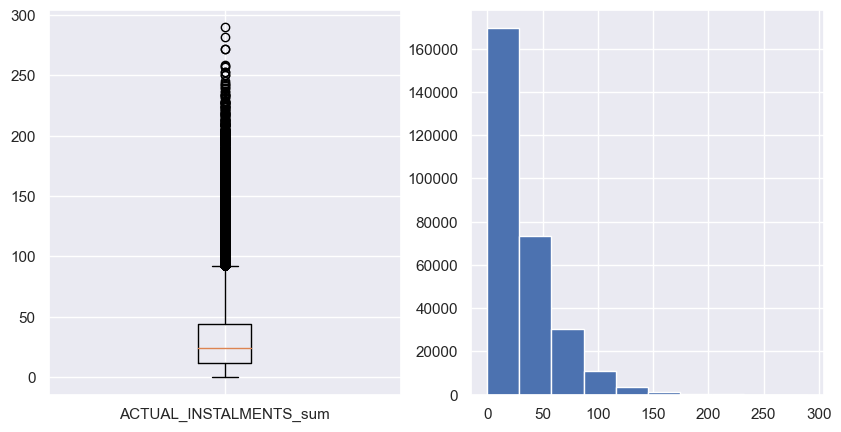

In [32]:
plot_hist_box(numerical_frame, 'ACTUAL_INSTALMENTS_sum')

Number of outliers : 47


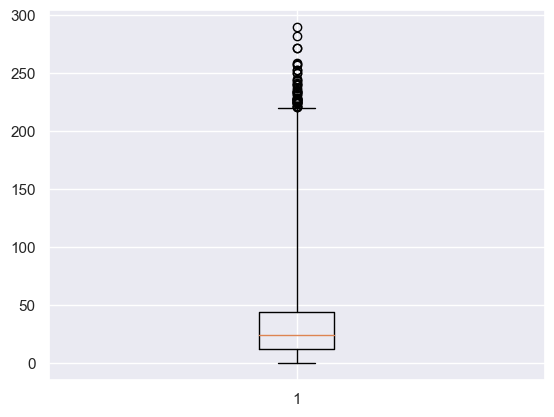

In [33]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''
plt.boxplot(numerical_frame['ACTUAL_INSTALMENTS_sum'].dropna(), whis=5.5);
q1, q3, iqr=calc_iqr('ACTUAL_INSTALMENTS_sum', numerical_frame)
numerical_frame['ACTUAL_INSTALMENTS_sum_outlier']=0
numerical_frame.loc[(numerical_frame['ACTUAL_INSTALMENTS_sum']<q1-5.5*iqr) | 
                    (numerical_frame['ACTUAL_INSTALMENTS_sum']>q3+5.5*iqr), 'ACTUAL_INSTALMENTS_sum_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['ACTUAL_INSTALMENTS_sum_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['ACTUAL_INSTALMENTS_sum_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

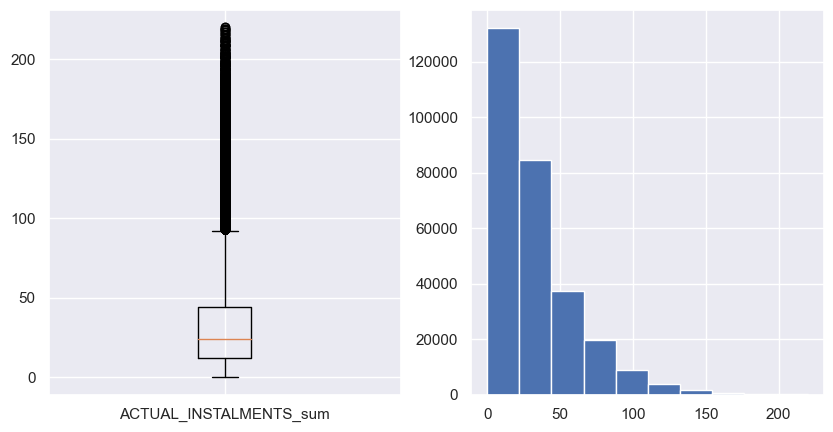

In [34]:
plot_hist_box(good_frame, 'ACTUAL_INSTALMENTS_sum')

Median of ACTUAL_INSTALMENTS_sum with target=0 : 24.000000
Median of ACTUAL_INSTALMENTS_sum with target=1 : 20.000000


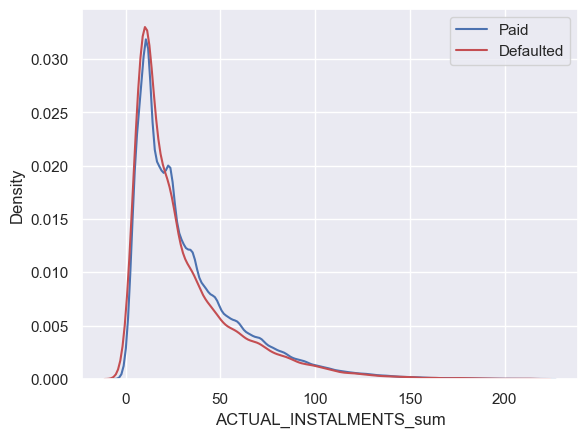

In [35]:
plot_kde_vs_target('ACTUAL_INSTALMENTS_sum', good_frame)
median_vs_target('ACTUAL_INSTALMENTS_sum', good_frame)

(-0.001, 7.0]    9.412580
(7.0, 11.0]      9.463322
(11.0, 15.0]     9.833151
(15.0, 21.0]     8.138775
(21.0, 26.0]     7.881120
(26.0, 35.0]     7.104403
(35.0, 48.0]     7.245635
(48.0, 68.0]     6.842593
(68.0, 220.0]    7.322004
Name: ACTUAL_INSTALMENTS_sum_binned, dtype: float64


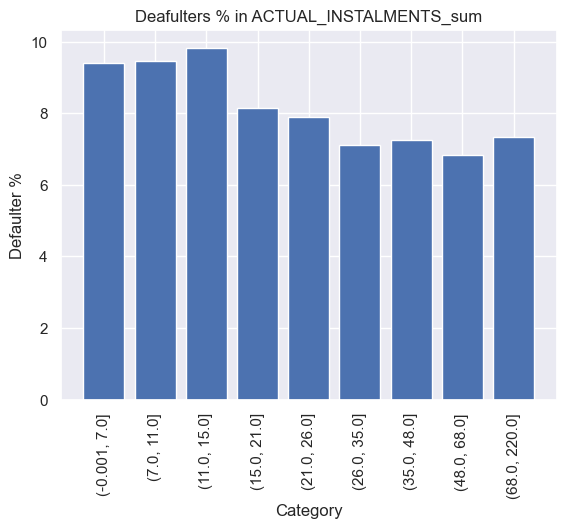

In [36]:
plot_hist_default_pct('ACTUAL_INSTALMENTS_sum', good_frame, 9)

### RECORD_count_max 

In [37]:
numerical_frame['RECORD_count_max'].isnull().sum()

0

In [38]:
numerical_frame['RECORD_count_max'].describe()

count    289444.000000
mean         14.397714
std           8.856920
min           1.000000
25%           9.000000
50%          13.000000
75%          18.000000
max          96.000000
Name: RECORD_count_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

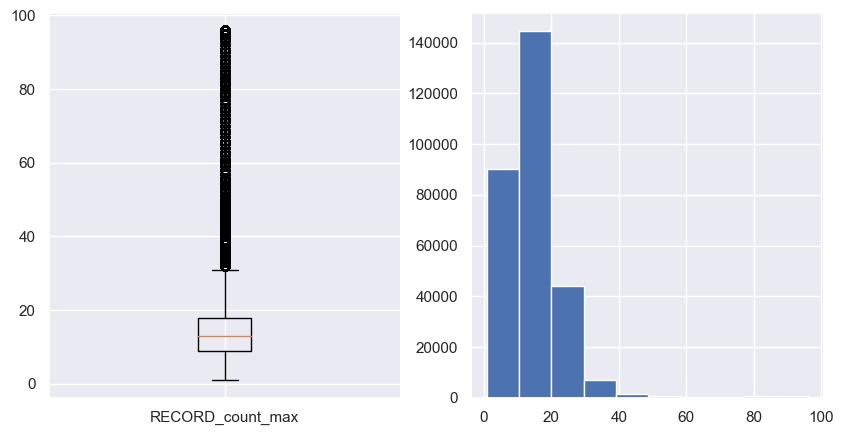

In [39]:
plot_hist_box(numerical_frame, 'RECORD_count_max')

Median of RECORD_count_max with target=0 : 13.000000
Median of RECORD_count_max with target=1 : 12.000000


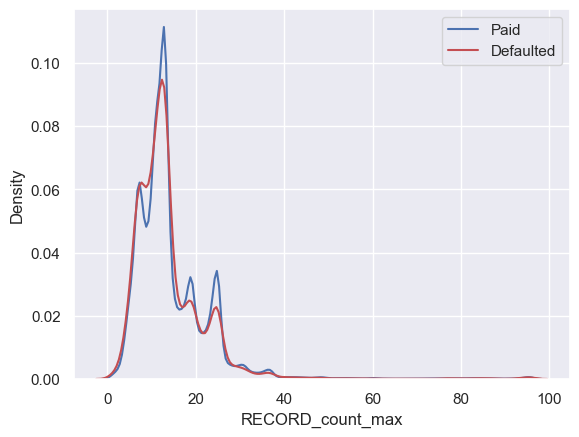

In [40]:
plot_kde_vs_target('RECORD_count_max', numerical_frame)
median_vs_target('RECORD_count_max', numerical_frame)

(0.999, 7.0]    8.768330
(7.0, 9.0]      9.435815
(9.0, 11.0]     8.028715
(11.0, 12.0]    8.256315
(12.0, 13.0]    8.036429
(13.0, 14.0]    9.228901
(14.0, 19.0]    7.836209
(19.0, 24.0]    7.039820
(24.0, 96.0]    7.282072
Name: RECORD_count_max_binned, dtype: float64


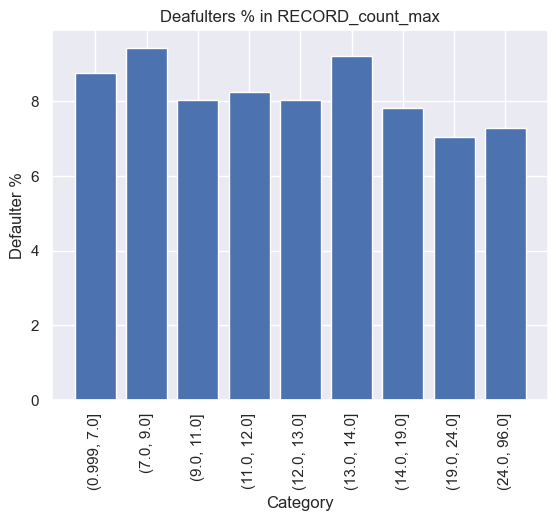

In [41]:
plot_hist_default_pct('RECORD_count_max', numerical_frame, 9)

### RECORD_count_sum (mi, more outliers but more variablity in graph) 

In [42]:
numerical_frame['RECORD_count_sum'].isnull().sum()

0

In [43]:
numerical_frame['RECORD_count_sum'].describe()

count    289444.000000
mean         29.516504
std          24.304535
min           1.000000
25%          12.000000
50%          22.000000
75%          39.000000
max         295.000000
Name: RECORD_count_sum, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

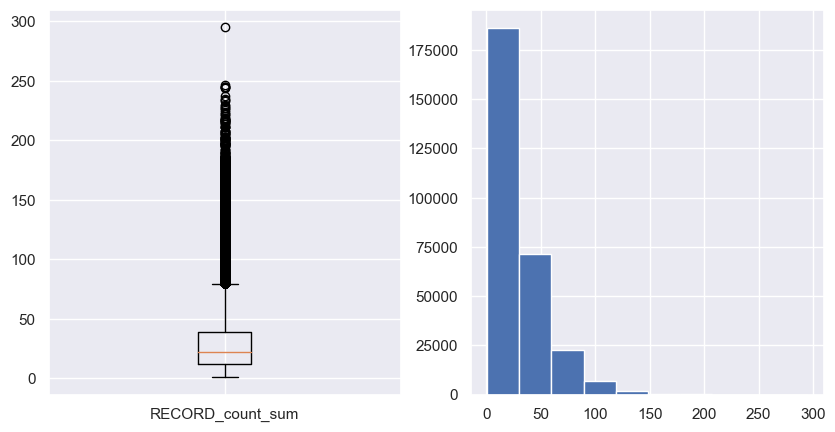

In [44]:
plot_hist_box(numerical_frame, 'RECORD_count_sum')

Number of outliers : 83


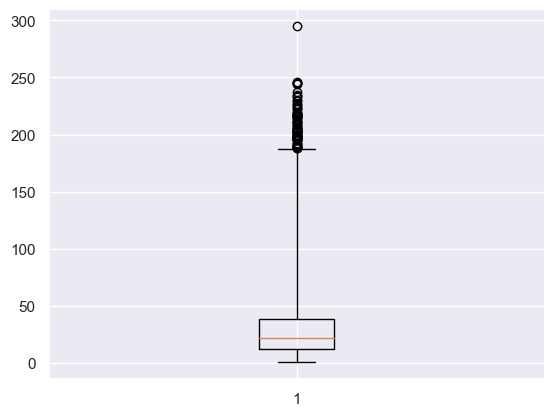

In [45]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''
plt.boxplot(numerical_frame['RECORD_count_sum'].dropna(), whis=5.5);
q1, q3, iqr=calc_iqr('RECORD_count_sum', numerical_frame)
numerical_frame['RECORD_count_sum_outlier']=0
numerical_frame.loc[(numerical_frame['RECORD_count_sum']<q1-5.5*iqr) | 
                    (numerical_frame['RECORD_count_sum']>q3+5.5*iqr), 'RECORD_count_sum_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['RECORD_count_sum_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['RECORD_count_sum_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

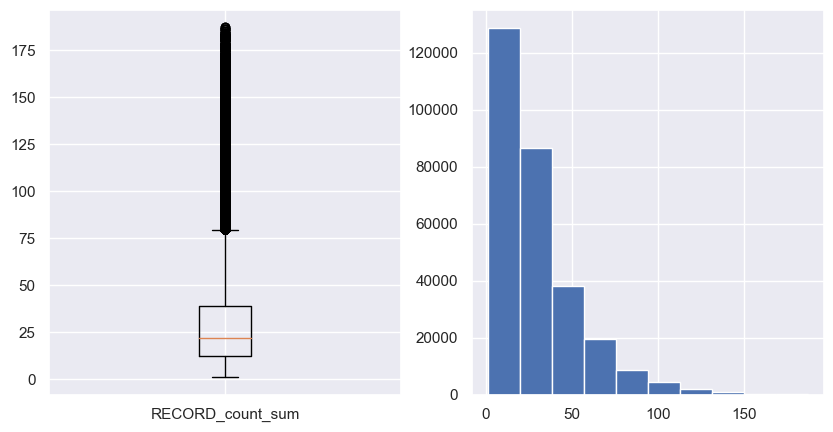

In [46]:
plot_hist_box(good_frame, 'RECORD_count_sum')

Median of RECORD_count_sum with target=0 : 23.000000
Median of RECORD_count_sum with target=1 : 19.000000


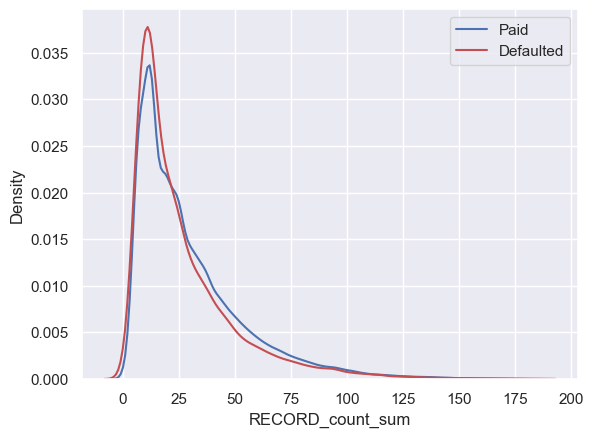

In [47]:
plot_kde_vs_target('RECORD_count_sum', good_frame)
median_vs_target('RECORD_count_sum', good_frame)

(0.999, 8.0]     9.424878
(8.0, 11.0]      9.913608
(11.0, 14.0]     9.825534
(14.0, 19.0]     8.572059
(19.0, 25.0]     8.110452
(25.0, 32.0]     7.334568
(32.0, 42.0]     7.075516
(42.0, 59.0]     6.539328
(59.0, 187.0]    6.602411
Name: RECORD_count_sum_binned, dtype: float64


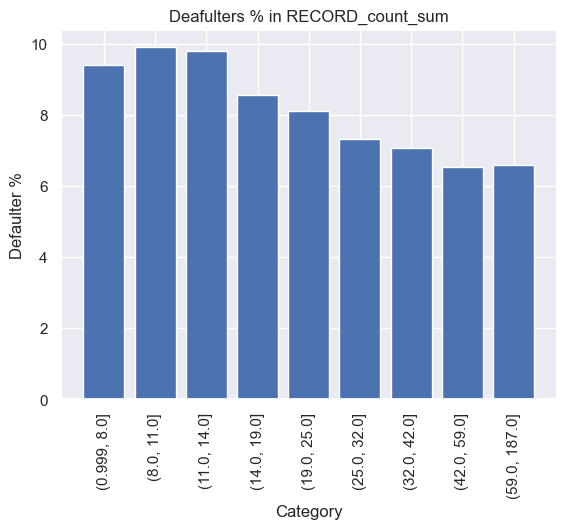

In [48]:
plot_hist_default_pct('RECORD_count_sum', good_frame, 9)

### INSTALMENT_REDUCTION_PCT_max

In [49]:
numerical_frame['INSTALMENT_REDUCTION_PCT_max'].isnull().sum()

24

In [50]:
numerical_frame['INSTALMENT_REDUCTION_PCT_max'].describe()

count    289420.000000
mean         27.490435
std          32.922750
min           0.000000
25%           0.000000
50%           8.333333
75%          58.333333
max          98.333333
Name: INSTALMENT_REDUCTION_PCT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

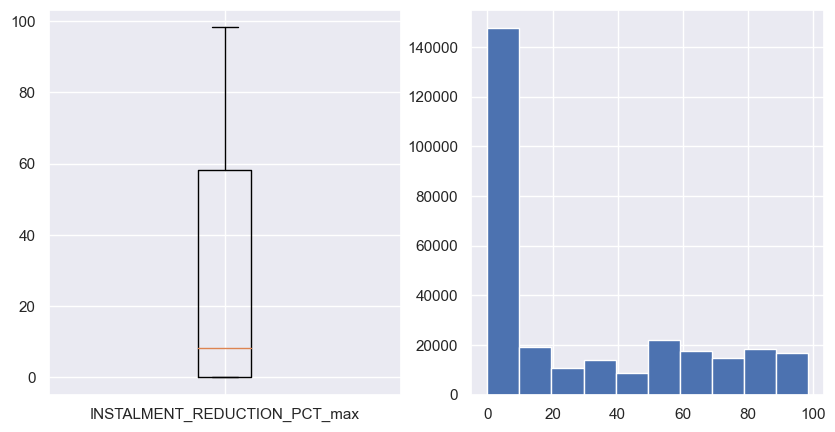

In [51]:
plot_hist_box(numerical_frame, 'INSTALMENT_REDUCTION_PCT_max')

Median of INSTALMENT_REDUCTION_PCT_max with target=0 : 8.333333
Median of INSTALMENT_REDUCTION_PCT_max with target=1 : 8.333333


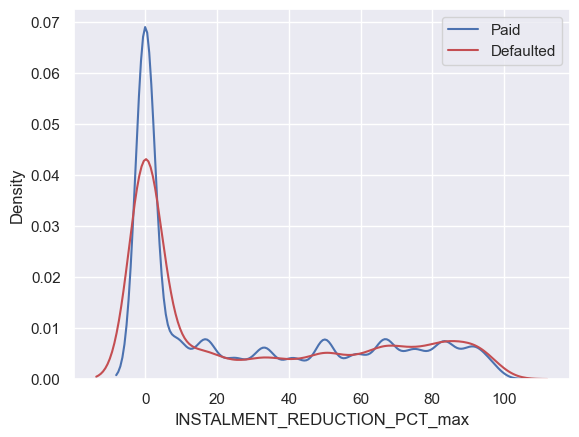

In [52]:
plot_kde_vs_target('INSTALMENT_REDUCTION_PCT_max', numerical_frame)
median_vs_target('INSTALMENT_REDUCTION_PCT_max', numerical_frame)

(-0.001, 16.667]    8.138983
(16.667, 41.667]    7.239485
(41.667, 62.5]      7.556914
(62.5, 80.556]      8.446503
(80.556, 98.333]    9.423705
Name: INSTALMENT_REDUCTION_PCT_max_binned, dtype: float64


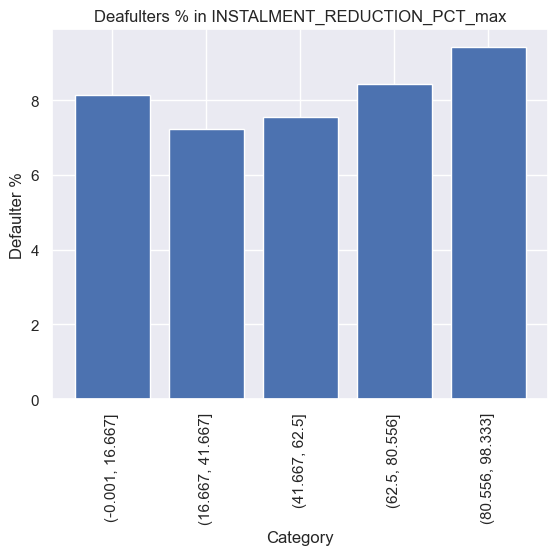

In [53]:
plot_hist_default_pct('INSTALMENT_REDUCTION_PCT_max', numerical_frame, 9)

### MONTHS_BALANCE_min (mi, more variability in graph)
recent most entry of the oldest loan

In [54]:
numerical_frame['MONTHS_BALANCE_min'].isnull().sum()

0

In [55]:
numerical_frame['MONTHS_BALANCE_min'].describe()

count    289444.000000
mean        -43.010178
std          30.282801
min         -96.000000
25%         -72.000000
50%         -40.000000
75%         -14.000000
max          -1.000000
Name: MONTHS_BALANCE_min, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

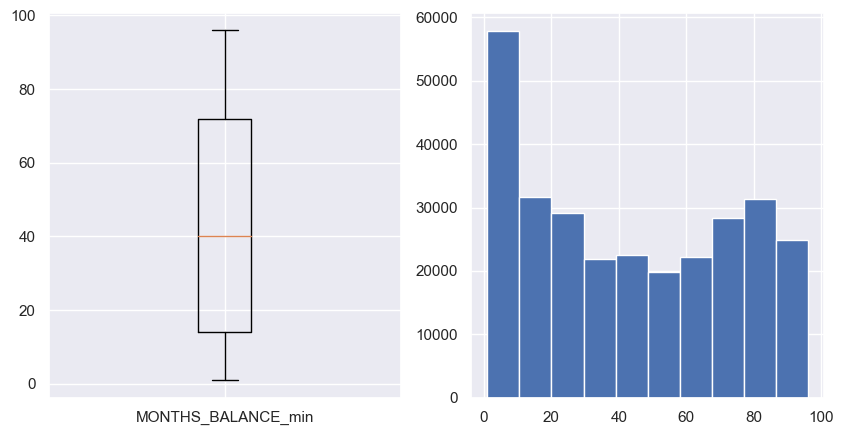

In [56]:
numerical_frame['MONTHS_BALANCE_min']=-(numerical_frame['MONTHS_BALANCE_min'])
plot_hist_box(numerical_frame, 'MONTHS_BALANCE_min')

Median of MONTHS_BALANCE_min with target=0 : 41.000000
Median of MONTHS_BALANCE_min with target=1 : 30.000000


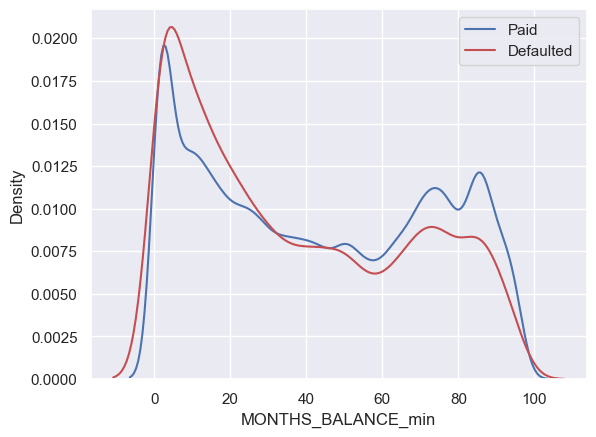

In [57]:
plot_kde_vs_target('MONTHS_BALANCE_min', numerical_frame)
median_vs_target('MONTHS_BALANCE_min', numerical_frame)

(0.999, 4.0]    10.120089
(4.0, 12.0]     10.661204
(12.0, 22.0]     9.585619
(22.0, 34.0]     8.209025
(34.0, 48.0]     7.956600
(48.0, 63.0]     7.220911
(63.0, 74.0]     7.046576
(74.0, 85.0]     6.577550
(85.0, 96.0]     5.780246
Name: MONTHS_BALANCE_min_binned, dtype: float64


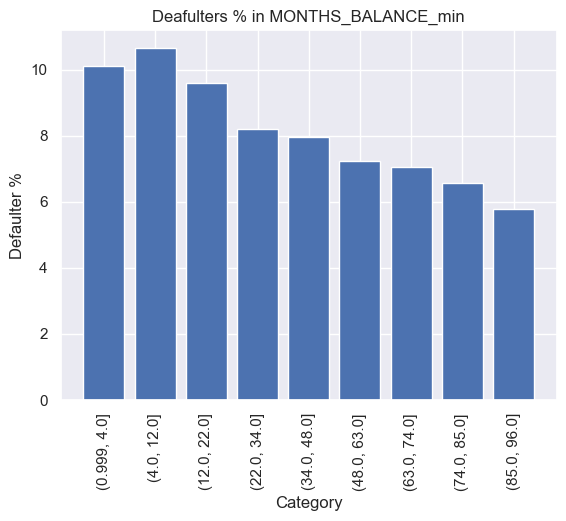

In [58]:
plot_hist_default_pct('MONTHS_BALANCE_min', numerical_frame, 9)

### MONTHS_BALANCE_median

In [59]:
numerical_frame['MONTHS_BALANCE_median'].isnull().sum()

0

In [60]:
numerical_frame['MONTHS_BALANCE_median'].describe()

count    289444.000000
mean        -25.869296
std          21.657546
min         -96.000000
25%         -38.500000
50%         -20.000000
75%          -8.000000
max          -1.000000
Name: MONTHS_BALANCE_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

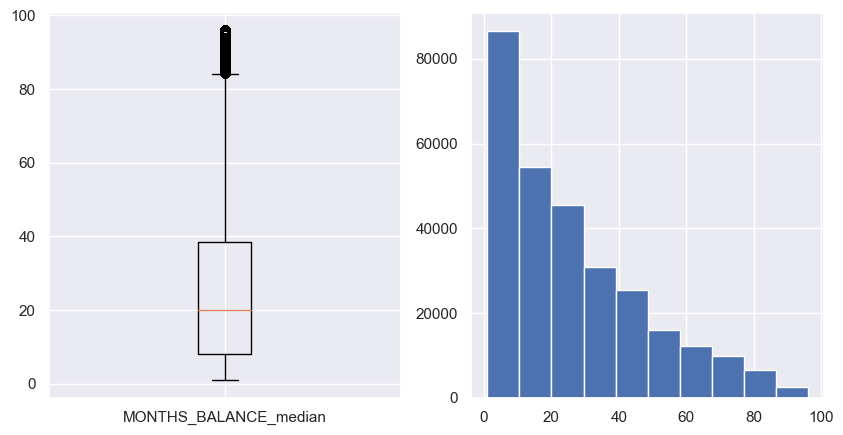

In [61]:
numerical_frame['MONTHS_BALANCE_median']=-(numerical_frame['MONTHS_BALANCE_median'])
plot_hist_box(numerical_frame, 'MONTHS_BALANCE_median')

Median of MONTHS_BALANCE_median with target=0 : 20.500000
Median of MONTHS_BALANCE_median with target=1 : 17.000000


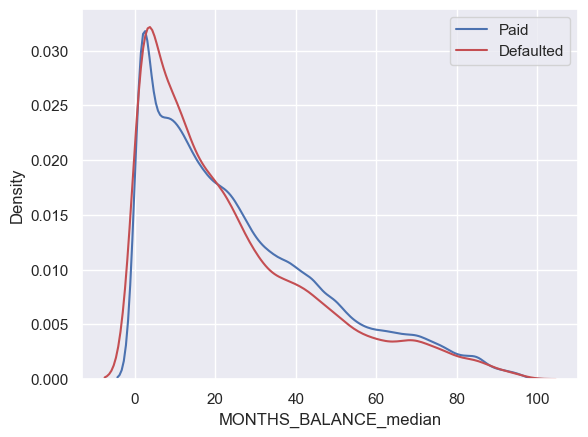

In [62]:
plot_kde_vs_target('MONTHS_BALANCE_median', numerical_frame)
median_vs_target('MONTHS_BALANCE_median', numerical_frame)

(0.999, 2.5]    9.900502
(2.5, 7.0]      9.494017
(7.0, 12.0]     9.084065
(12.0, 17.0]    8.121171
(17.0, 23.5]    8.166247
(23.5, 31.0]    7.484292
(31.0, 41.0]    6.928267
(41.0, 56.5]    7.018915
(56.5, 96.0]    7.100131
Name: MONTHS_BALANCE_median_binned, dtype: float64


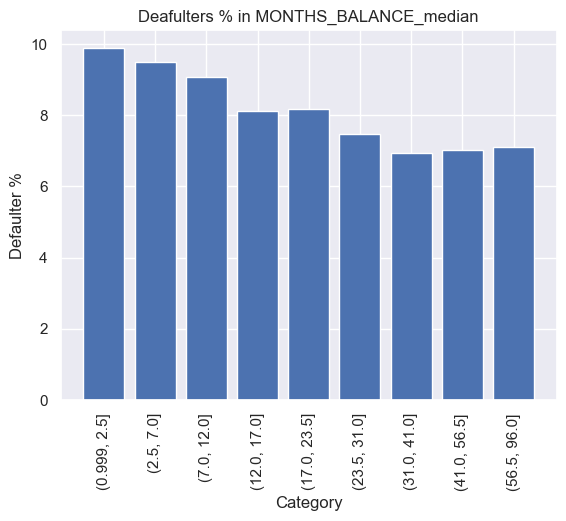

In [63]:
plot_hist_default_pct('MONTHS_BALANCE_median', numerical_frame, 9)

### CONTRACT_STATUS_Active_PCT

In [64]:
numerical_frame['CONTRACT_STATUS_Active_PCT'].isnull().sum()

0

In [65]:
numerical_frame['CONTRACT_STATUS_Active_PCT'].describe()

count    289444.000000
mean         27.434917
std          32.769582
min           0.000000
25%           0.000000
50%          20.000000
75%          50.000000
max         100.000000
Name: CONTRACT_STATUS_Active_PCT, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

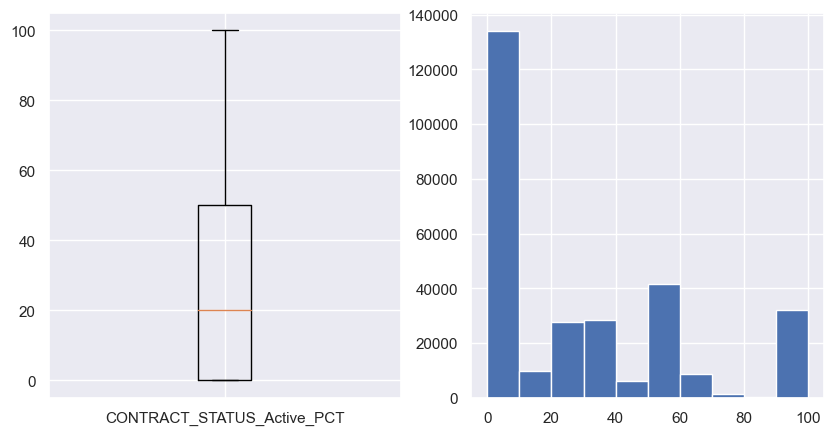

In [66]:
plot_hist_box(numerical_frame, 'CONTRACT_STATUS_Active_PCT')

Median of CONTRACT_STATUS_Active_PCT with target=0 : 20.000000
Median of CONTRACT_STATUS_Active_PCT with target=1 : 0.000000


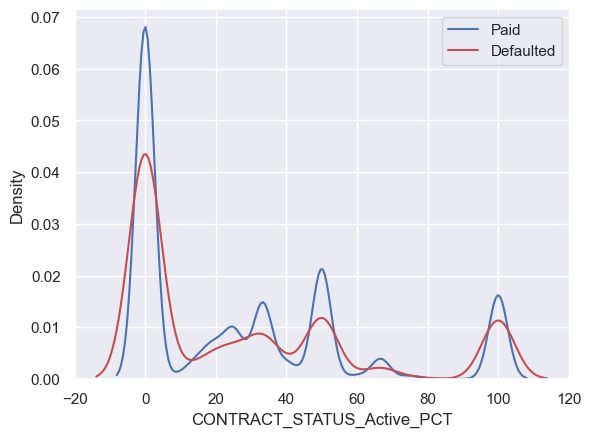

In [67]:
plot_kde_vs_target('CONTRACT_STATUS_Active_PCT', numerical_frame)
median_vs_target('CONTRACT_STATUS_Active_PCT', numerical_frame)

(-0.001, 25.0]    8.358248
(25.0, 33.333]    6.961178
(33.333, 50.0]    7.450643
(50.0, 80.0]      7.056630
(80.0, 100.0]     9.641521
Name: CONTRACT_STATUS_Active_PCT_binned, dtype: float64


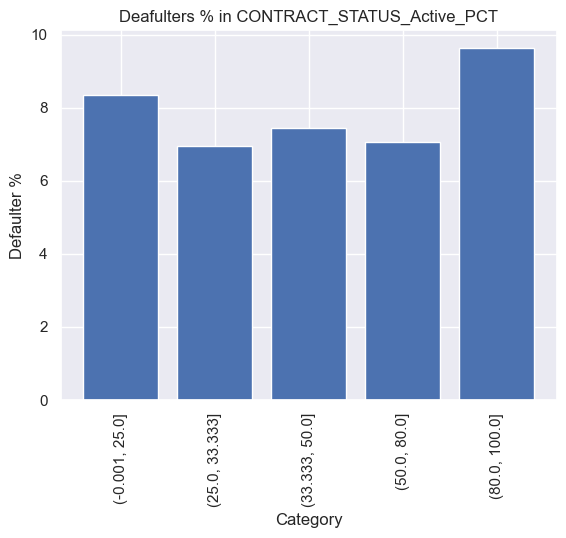

In [68]:
plot_hist_default_pct('CONTRACT_STATUS_Active_PCT', numerical_frame, 9)

### CONTRACT_STATUS_Completed_PCT

In [69]:
numerical_frame['CONTRACT_STATUS_Completed_PCT'].isnull().sum()

0

In [70]:
numerical_frame['CONTRACT_STATUS_Completed_PCT'].describe()

count    289444.000000
mean         72.382386
std          32.812338
min           0.000000
25%          50.000000
50%          80.000000
75%         100.000000
max         100.000000
Name: CONTRACT_STATUS_Completed_PCT, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

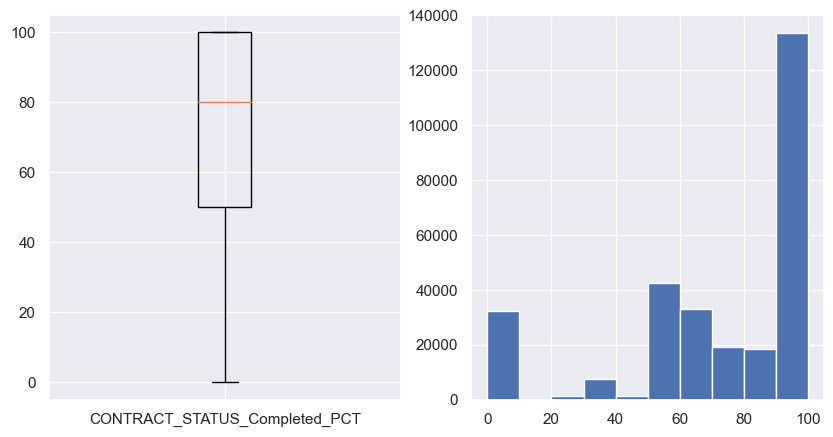

In [71]:
plot_hist_box(numerical_frame, 'CONTRACT_STATUS_Completed_PCT')

Median of CONTRACT_STATUS_Completed_PCT with target=0 : 80.000000
Median of CONTRACT_STATUS_Completed_PCT with target=1 : 90.000000


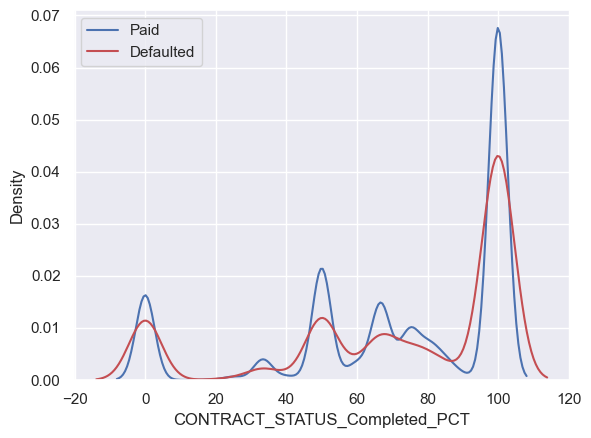

In [72]:
plot_kde_vs_target('CONTRACT_STATUS_Completed_PCT', numerical_frame)
median_vs_target('CONTRACT_STATUS_Completed_PCT', numerical_frame)

(-0.001, 50.0]    8.390454
(50.0, 66.667]    6.837582
(66.667, 75.0]    6.294925
(75.0, 100.0]     8.553760
Name: CONTRACT_STATUS_Completed_PCT_binned, dtype: float64


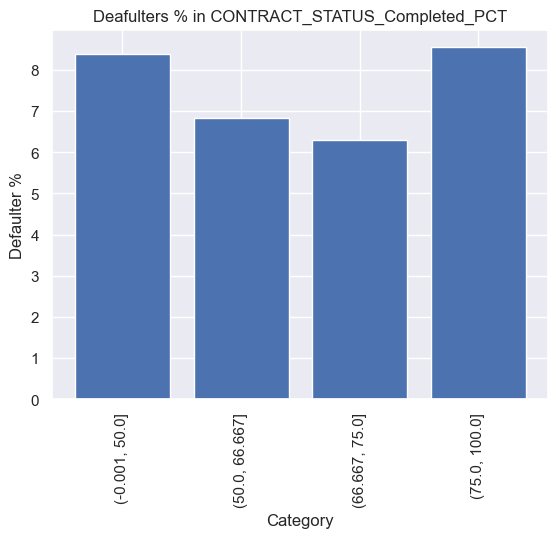

In [73]:
plot_hist_default_pct('CONTRACT_STATUS_Completed_PCT', numerical_frame, 9)

### Dropping Unimportatnt Variables

In [74]:
numerical_frame.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'ACTUAL_INSTALMENTS_sum_outlier',
       'CONTRACT_STATUS_Active_PCT', 'CONTRACT_STATUS_Completed_PCT',
       'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
       'MONTHS_BALANCE_min', 'RECORD_count_max', 'RECORD_count_sum',
       'RECORD_count_sum_outlier', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [75]:
numerical_frame.drop(labels=['RECORD_count_max', 'CONTRACT_STATUS_Completed_PCT'],
                     axis=1, inplace=True)
numerical_frame.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'ACTUAL_INSTALMENTS_sum_outlier',
       'CONTRACT_STATUS_Active_PCT', 'INSTALMENT_REDUCTION_PCT_max',
       'MONTHS_BALANCE_median', 'MONTHS_BALANCE_min', 'RECORD_count_sum',
       'RECORD_count_sum_outlier', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

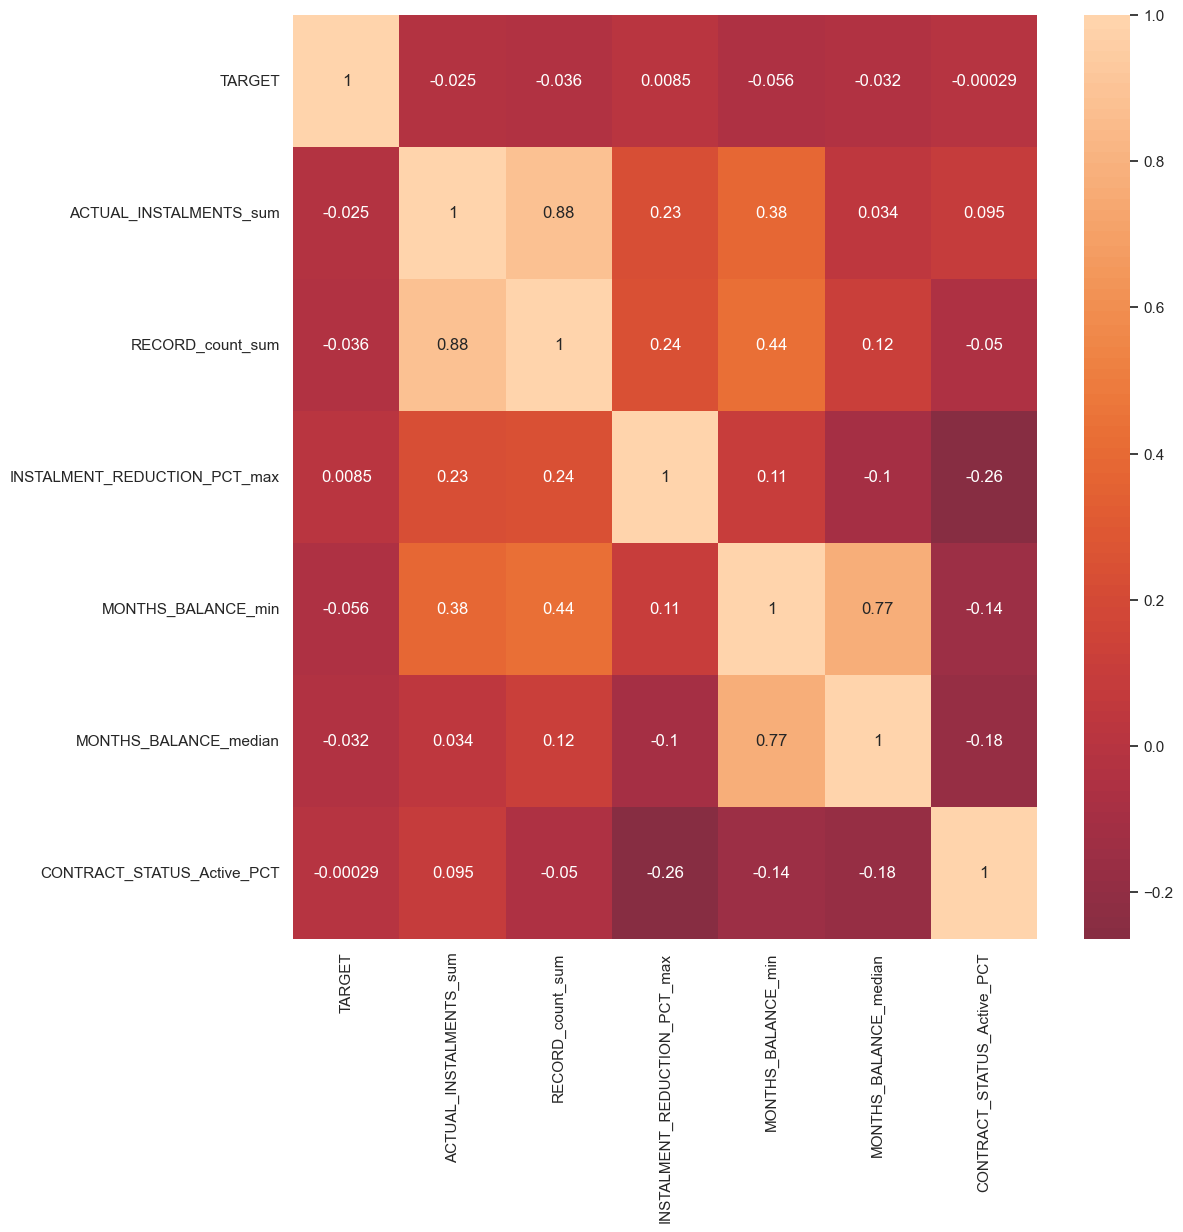

In [76]:
ax=sns.heatmap(numerical_frame.drop(labels=['SK_ID_CURR', 'ACTUAL_INSTALMENTS_sum_outlier',
                                            'RECORD_count_sum_outlier'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)

In [77]:
numerical_frame.to_csv('initial_clean_pos.csv', index=False)